# Simple self-created spelled-out Neural Network
## Test: Balancing a cart on a pole
Reference: [Article](https://sharpneat.sourceforge.io/research/cart-pole/cart-pole-equations.html)

#### Imports

In [ ]:
import math 
import random 
from engine import Data 
from nn import MLP
from show import Show
import matplotlib.pyplot as plt

#### Creating env

In [43]:
class PEnv:
    def __init__(self):
        self.g = 9.8
        self.m_cart = 1.0
        self.m_pole = 0.1
        self.l_pole = 0.5 
        self.dt = 0.02 
        self.reset()

    def reset(self):
        self.state = [0.0, 0.0, random.uniform(-0.1, 0.1), 0.0]
        # [pos_x_cart, vel_x_cart, angle_x_pole, vel_x_pole]
        return self.wrap()
    
    def wrap(self):
        return [Data(v) for v in self.state]

    def next(self, action):
        # action 0: left
        # action 1: right
        f_action = 10.0 if action == 1 else -10.0
        pos_x_cart, vel_x_cart, angle_x_pole, vel_x_pole = self.state
        
        # cos and sine calculations
        costheta = math.cos(angle_x_pole)
        sintheta = math.sin(angle_x_pole)

        # centripetal force
        # F_centri = action_force + mass_pole * l_pole * ang_vel^2 / total_mass
        # ang_acc on pole (consider uniform pole) = a
        #   = (gravity) g sintheta - F_centri costhetha /  ((l_pole*4/3 - l_pole*mass_pole*costheta^2) / total_mass)
        # acc_x = f_centri - (m_pole * l_pole * ang_acc*sintheta/total_mass)
        f_centri = (f_action + self.m_pole*self.l_pole*angle_x_pole*angle_x_pole) / (self.m_pole + self.m_cart)
        ang_acc_pole = (self.g*sintheta - f_centri*costheta) / ((self.l_pole*4/3 - self.l_pole*self.m_pole*costheta*costheta) / (self.m_pole*self.m_cart))
        acc_x = f_centri - self.m_pole*self.l_pole*ang_acc_pole*costheta / (self.m_cart + self.m_pole)

        pos_x_cart += self.dt*vel_x_cart
        vel_x_cart += self.dt*acc_x
        angle_x_pole += self.dt*vel_x_pole
        vel_x_pole += self.dt*ang_acc_pole

        self.state = [pos_x_cart, vel_x_cart, angle_x_pole, vel_x_pole]

        # Fail conditions: Cart moves too far, or pole falls past 12 degrees
        fail = pos_x_cart < -2.4 or pos_x_cart > 2.4 or angle_x_pole < -0.209 or angle_x_pole > 0.209
        reward = 0.0 if fail else 1.0

        return self.wrap(), reward, fail   

#### Training

- In standard supervised learning, we have a y (ground truth), and we calculate loss on the basis of that.
- Here, we need to invent one: based on the BELLMAN EQUATION
- q_val based on model NOW (predicted) <VS> what q_val SHOULD be based on real world (target)
- In standard Supervised Learning (like predicting house prices), the target y is a fixed constant from a dataset. In DQN, your target is derived from the model itself.
- During backprop, you update your gradients to match with current absolute(target). But here if you do that, it becomes circular
- We would be updating the weights to make the future look like the current and vice versa simultaneously.
- Backpropping through curr_state_as_per_world (the 'y_target', in this case) will create divergence due to the moving target problem, by reducing next states rather than increasing current ones to align
- backprop essentially means *change the weights to minimize the distance between the current state and the next state*
- backprop does: change weights so that y_target moves closer to y_predict
- what we WANT: change weights so that y_predict moves closer to y_target

IMP!

In [67]:
env = PEnv()
mlp = MLP(4, [16, 16, 2])
# input: 4 (state)
# output: [q_val for left, q_val for right]

# mlp_policy = MLP(4, [16, 16, 2])
# mlp_target = MLP(4, [16, 16, 2])

Define params sync: sync params: for DQN, such that parmas don't go way out of hand
- Copies the weights, biases from policy_net to target_net.
- Only the .data (float) is copied to ensure the target_net remains detached from the policy_net's computational graph.

SOLUTION TO EXPLODING values/ positive feedback loop:
- need to keep a copy of the model frozen in time only to calc q_next, sync weights every x(=1000, say) steps
- TODO: implement policy network vs target network params 

In [66]:
# unused
def sync_networks(policy_net, target_net):
    p_params = policy_net.params()
    t_params = target_net.params()

    for p, t in zip(p_params, t_params):
        t.data = p.data 

In [ ]:
gamma = 0.95
epsilon = 1.0 
epsilon_decay = 0.995
lr = 0.001

pos_cart = []
angles_cart = []
reward_history = []

for epoch in range(100):
    state = env.reset()
    total_reward = 0

    # max steps per epoch/episode
    for t in range(200):

        # greedy action decider
        if random.random() < epsilon:
            action = random.choice([0, 1]) # explore
        else:
            q = mlp(state) # q=[vale of going left, value of going right]
            action = 0 if q[0].data > q[1].data else 1 
            # remember, action=0:go left, action=1:go right

        # y_target: calc optimal output as per curr env
        next_state, reward, fail = env.next(action)
        total_reward += reward

        pos_cart.append(state[0].data)
        angles_cart.append(state[2].data)
        reward_history.append(reward)

        # after doing action, what is supposed to be the next action?
        # DETATCH: create a new Data() - not linked to the backprop. for ideal calculations!
        # needed for reward calculation
        q_next = mlp(next_state)
        max_q_next = max(q_next[0].data, q_next[1].data)
        q_target = Data(reward if fail else reward + gamma*max_q_next) # gamma: prioritize immediate action vs later action

        # forward pass
        for p in mlp.params():
            p.grad = 0.0
        
        q = mlp(state)
        q_pred = q[action] # value of the action actually taken
        loss = (q_pred - q_target)**2 

        # backpropogation
        loss.backprop()

        # update weights
        for p in mlp.params():
            # keep gradients within range [-1, 1]
            if p.grad > 1.0: p.grad = 1.0
            if p.grad < -1.0: p.grad = -1.0
            p.data -= lr*p.grad
        
        state = next_state 
        if fail:
            break


    epsilon = max(0.01, epsilon*epsilon_decay) # update exploration: lesser as time goes by

    if epoch % 20 == 0:
        print(f"epoch {epoch} | score: {total_reward} | epsilon: {epsilon:.2f}")
        

epoch 0 | score: 47.0 | epsilon: 0.99
epoch 20 | score: 194.0 | epsilon: 0.90
epoch 40 | score: 16.0 | epsilon: 0.81
epoch 60 | score: 46.0 | epsilon: 0.74
epoch 80 | score: 64.0 | epsilon: 0.67


#### Visualising

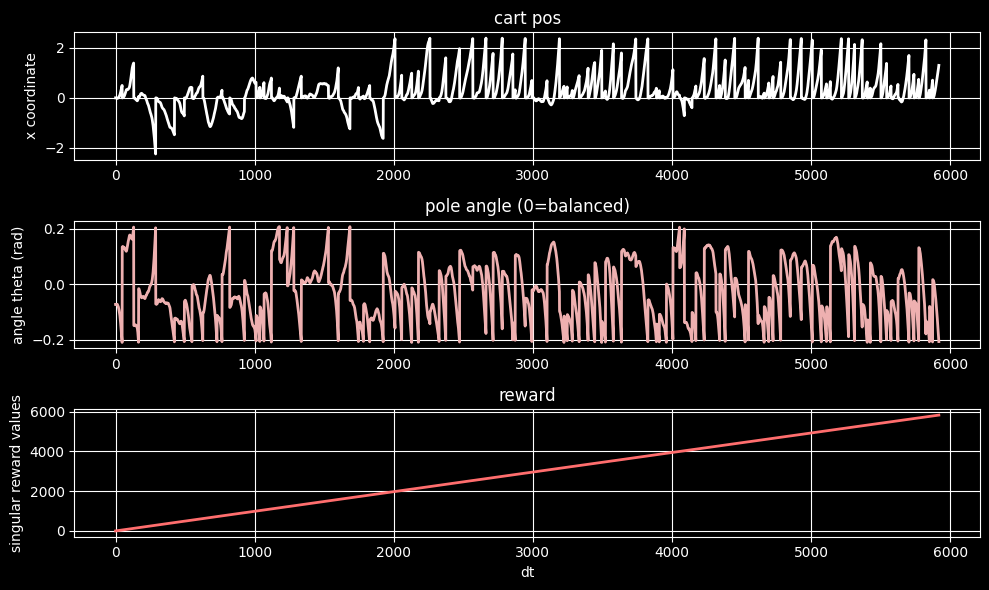

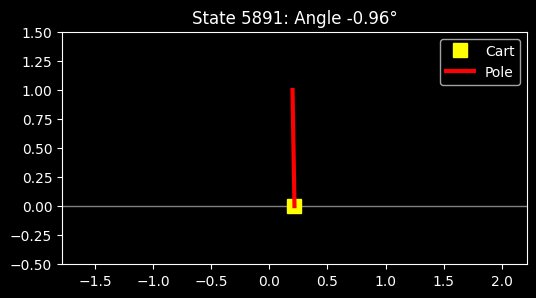

In [68]:
# plotting
def plotdata():
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 6))
    
    ax1.plot(pos_cart, color="#FFFFFF", linewidth=2)
    ax1.set_title("cart pos")
    ax1.set_ylabel("x coordinate")
    ax1.grid(True)
    
    ax2.plot(angles_cart, color="#EEB0B0", linewidth=2)
    ax2.set_title("pole angle (0=balanced)")
    ax2.set_ylabel("angle theta (rad)")
    ax2.grid(True)

    # cumulative reward
    reward_cum = [sum(reward_history[:i]) for i in range(len(reward_history))]
    ax3.plot(reward_cum, color="#FF6D6D", linewidth=2)
    ax3.set_title("reward")
    ax3.set_ylabel("singular reward values")
    ax3.grid(True)
    
    ax3.set_xlabel("dt")

    plt.tight_layout()
    plt.show()

def plot_final_pos(index):
    fig, ax = plt.subplots(figsize=(6, 6))    
    x = pos_cart[index]
    theta = angles_cart[index] 
    L = 1.0
    tip_x = x + L * math.sin(theta)
    tip_y = L * math.cos(theta)
    
    # ground
    ax.axhline(0, color='grey', lw=1)
    
    # cart
    ax.plot(x, 0, 's', color='yellow', markersize=10, label='Cart') 
    
    # the line
    ax.plot([x, tip_x], [0, tip_y], color='r', lw=3, label='Pole')
    
    ax.set_xlim(x - 2, x + 2) # center
    ax.set_ylim(-0.5, 1.5)
    ax.set_aspect('equal') # aspect ratio
    ax.legend()
    ax.set_title(f"State {'FINAL' if index == -1 else index+1}: Angle {math.degrees(theta):.2f}°")
    plt.show()

plotdata()
plot_final_pos(len(angles_cart)-30)

In [77]:
show = Show(loss)
show.show()

TypeError: trace() takes 1 positional argument but 2 were given